In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\USER\PycharmProjects\component2_traffic\traffic_simulation\final_dataset_dynamic.csv")

In [2]:
# Quick preview
print(df.head()) 


   vehicle_id system_type  depart_time  arrival_time  duration  waiting_time  \
0           0     dynamic          0.0          68.0      68.0           0.0   
1          22     dynamic         33.0         125.0      92.0           0.0   
2          28     dynamic         42.0         128.0      86.0           0.0   
3          40     dynamic         60.0         145.0      85.0           0.0   
4          23     dynamic         35.0         181.0     146.0          45.0   

   time_loss  route_length  average_speed  waiting_ratio  delay_ratio  
0       7.87        863.15      12.693382       0.000000     0.115735  
1      10.50        681.20       7.404348       0.000000     0.114130  
2       9.05        719.84       8.370233       0.000000     0.105233  
3      10.58        724.48       8.523294       0.000000     0.124471  
4      67.13        674.91       4.622671       0.308219     0.459795  


In [3]:
# Dataset summary
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   vehicle_id     1948 non-null   int64  
 1   system_type    1948 non-null   str    
 2   depart_time    1948 non-null   float64
 3   arrival_time   1948 non-null   float64
 4   duration       1948 non-null   float64
 5   waiting_time   1948 non-null   float64
 6   time_loss      1948 non-null   float64
 7   route_length   1948 non-null   float64
 8   average_speed  1948 non-null   float64
 9   waiting_ratio  1948 non-null   float64
 10  delay_ratio    1948 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 167.5 KB
None


In [4]:
# Statistical summary
print(df.describe())

        vehicle_id  depart_time  arrival_time     duration  waiting_time  \
count  1948.000000  1948.000000   1948.000000  1948.000000   1948.000000   
mean   1060.504107  1591.105236   1981.434805   390.329569    127.361910   
std     638.166422   957.281902    948.891089   308.627836    258.277062   
min       0.000000     0.000000     68.000000     8.000000      0.000000   
25%     509.750000   764.750000   1175.000000   219.000000     14.750000   
50%    1035.500000  1553.500000   2012.000000   337.000000     61.000000   
75%    1605.250000  2408.250000   2772.750000   477.000000    128.000000   
max    2347.000000  3521.000000   3596.000000  3238.000000   2779.000000   

         time_loss  route_length  average_speed  waiting_ratio  delay_ratio  
count  1948.000000   1948.000000    1948.000000    1948.000000  1948.000000  
mean    185.910339   2670.100488       7.789657       0.223748     0.386768  
std     275.603393   1254.021962       2.219877       0.194075     0.189355  
min

In [5]:
#Check Missing Values
print(df.isnull().sum())

vehicle_id       0
system_type      0
depart_time      0
arrival_time     0
duration         0
waiting_time     0
time_loss        0
route_length     0
average_speed    0
waiting_ratio    0
delay_ratio      0
dtype: int64


In [6]:
df.fillna(df.median(numeric_only=True), inplace=True)

,vehicle_id,system_type,depart_time,arrival_time,duration,waiting_time,time_loss,route_length,average_speed,waiting_ratio,delay_ratio
0,0,dynamic,0.0,68.0,68.0,0.0,7.87,863.15,12.693382,0.000000,0.115735
1,22,dynamic,33.0,125.0,92.0,0.0,10.50,681.20,7.404348,0.000000,0.114130
2,28,dynamic,42.0,128.0,86.0,0.0,9.05,719.84,8.370233,0.000000,0.105233
3,40,dynamic,60.0,145.0,85.0,0.0,10.58,724.48,8.523294,0.000000,0.124471
4,23,dynamic,35.0,181.0,146.0,45.0,67.13,674.91,4.622671,0.308219,0.459795
...,...,...,...,...,...,...,...,...,...,...,...
1943,2179,dynamic,3269.0,3590.0,321.0,59.0,90.74,2391.04,7.448723,0.183801,0.282679
1944,989,dynamic,1484.0,3591.0,2107.0,1504.0,1743.95,5951.56,2.824661,0.713811,0.827693
1945,2009,dynamic,3014.0,3591.0,577.0,73.0,167.21,3630.78,6.292513,0.126516,0.289792
1946,1985,dynamic,2978.0,3592.0,614.0,101.0,200.69,4477.47,7.292296,0.164495,0.326857


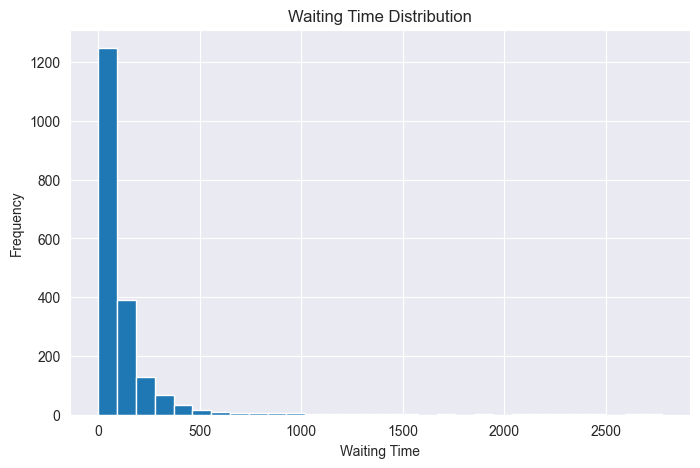

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["waiting_time"], bins=30)
plt.xlabel("Waiting Time")
plt.ylabel("Frequency")
plt.title("Waiting Time Distribution")
plt.show()

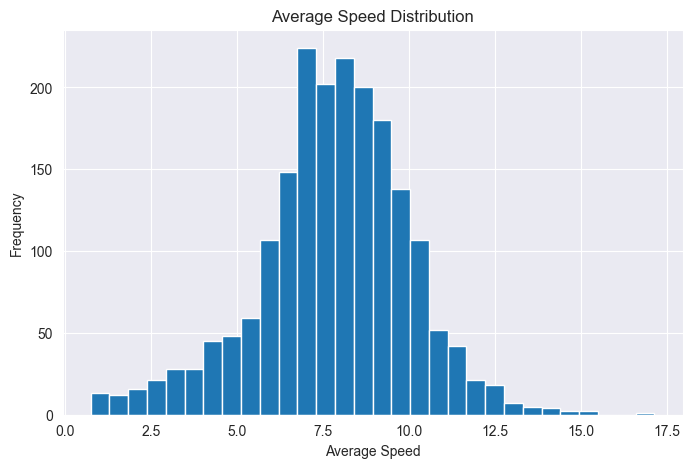

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["average_speed"], bins=30)
plt.xlabel("Average Speed")
plt.ylabel("Frequency")
plt.title("Average Speed Distribution")
plt.show()

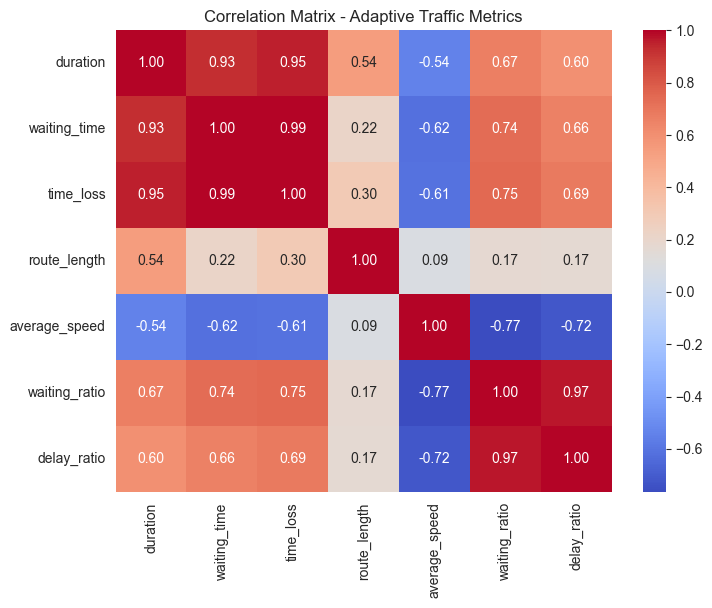

In [9]:
import seaborn as sns

cols = [
    "duration",
    "waiting_time",
    "time_loss",
    "route_length",
    "average_speed",
    "waiting_ratio",
    "delay_ratio"
]

corr_matrix = df[cols].corr()

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Adaptive Traffic Metrics")
plt.show()


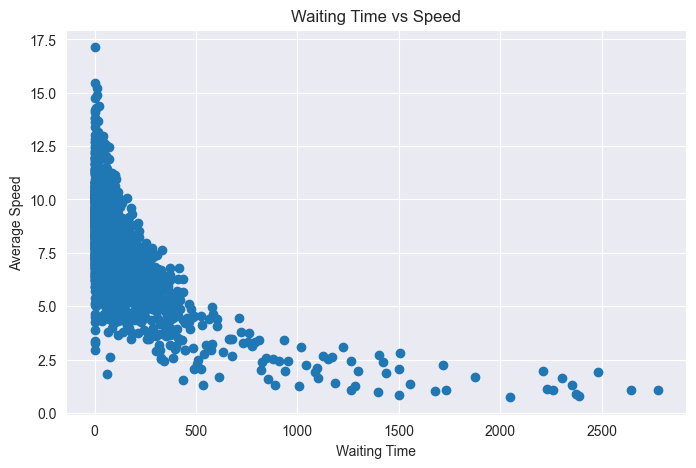

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["waiting_time"], df["average_speed"])
plt.xlabel("Waiting Time")
plt.ylabel("Average Speed")
plt.title("Waiting Time vs Speed")
plt.show()

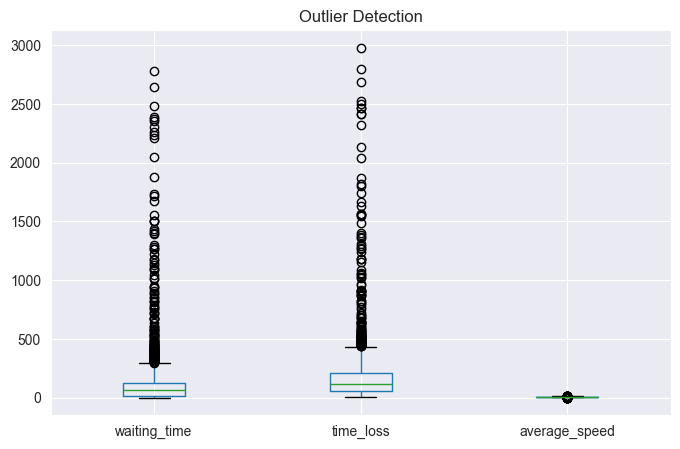

In [11]:
#Outlier Detection
plt.figure(figsize=(8,5))
df[["waiting_time","time_loss","average_speed"]].boxplot()
plt.title("Outlier Detection")
plt.show()